In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
FILE = "/ofo-share/repos/david/tree-species-prediction/scratch/matching_stats.csv"

data = pd.read_csv(FILE)
data

,F1,precision,recall,n_core_field,n_core_drone,n_field_matched,n_drone_matched,dataset_id
0,0.826667,0.815789,0.837838,37,38,31,31,0001_001435_001436
1,0.659062,0.606061,0.722222,54,66,39,40,0003_001438_001437
2,0.857189,0.819672,0.898305,59,61,53,50,0004_000285_000293
3,0.769395,0.840909,0.709091,55,44,39,37,0005_000147_000145
4,0.793323,0.711864,0.895833,48,59,43,42,0006_000142_000141
...,...,...,...,...,...,...,...,...
146,0.000000,0.000000,0.000000,0,0,0,0,0222_000315_000314
147,0.000000,0.000000,0.000000,1,1,0,0,0223_000315_000314
148,1.000000,1.000000,1.000000,1,1,1,1,0224_000315_000314
149,0.333333,0.200000,1.000000,1,5,1,1,0233_000315_000314


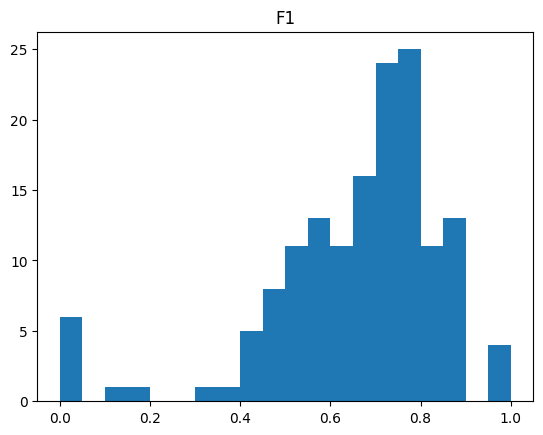

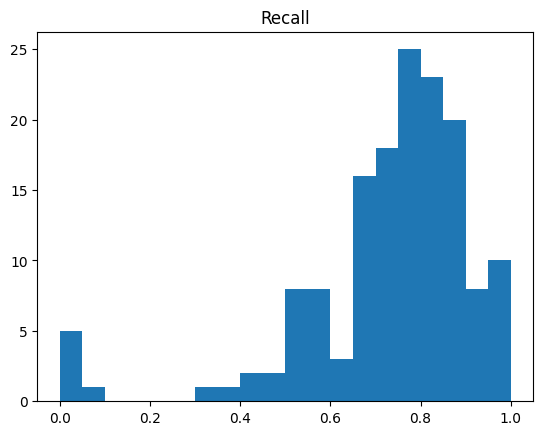

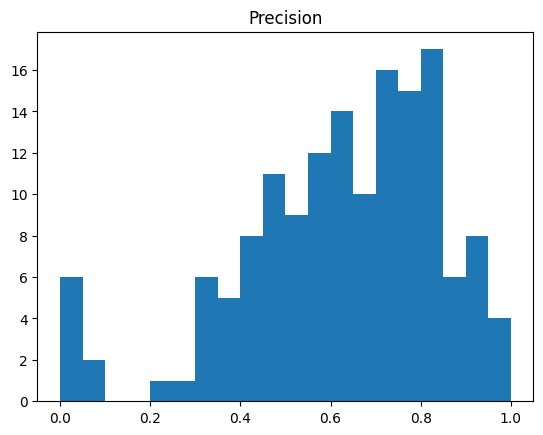

In [42]:
plt.hist(data["F1"], bins=20)
plt.title("F1")
plt.show()
plt.close()

plt.hist(data["recall"], bins=20)
plt.title("Recall")
plt.show()
plt.close()

plt.hist(data["precision"], bins=20)
plt.title("Precision")
plt.show()
plt.close()

In [29]:
mean_values = data.mean(axis=0)
mean_values

F1                   0.654520
precision            0.621999
recall               0.729663
n_core_field        96.609272
n_core_drone       115.245033
n_field_matched     71.450331
n_drone_matched     70.192053
dataset_id                inf
dtype: float64

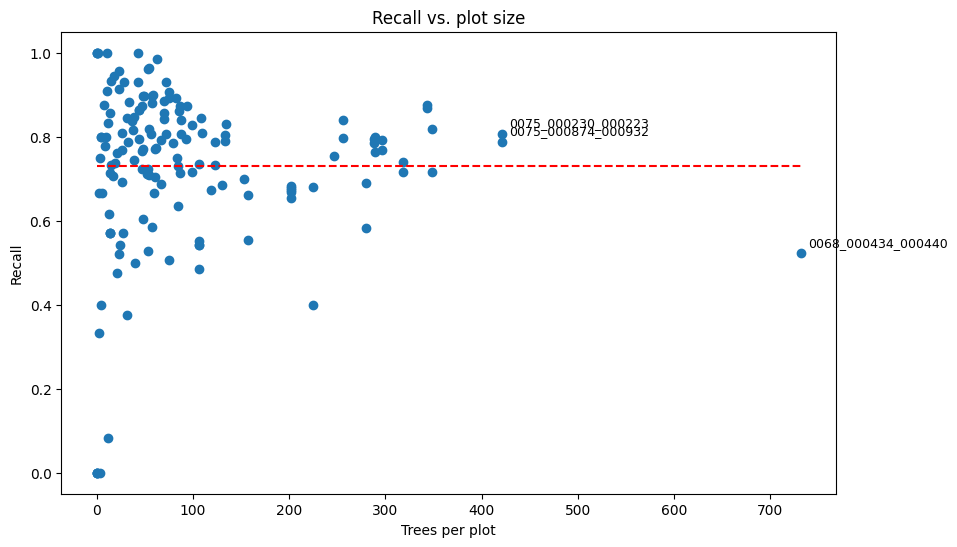

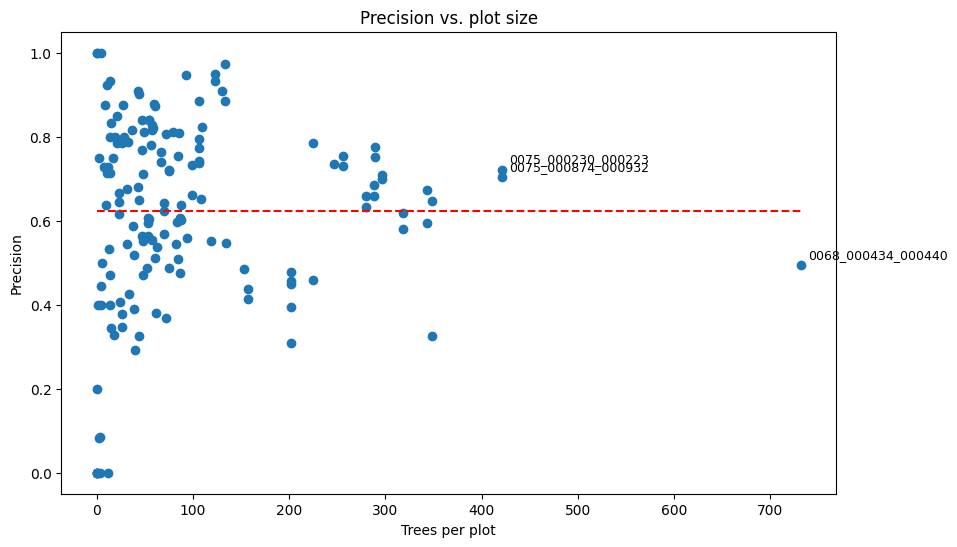

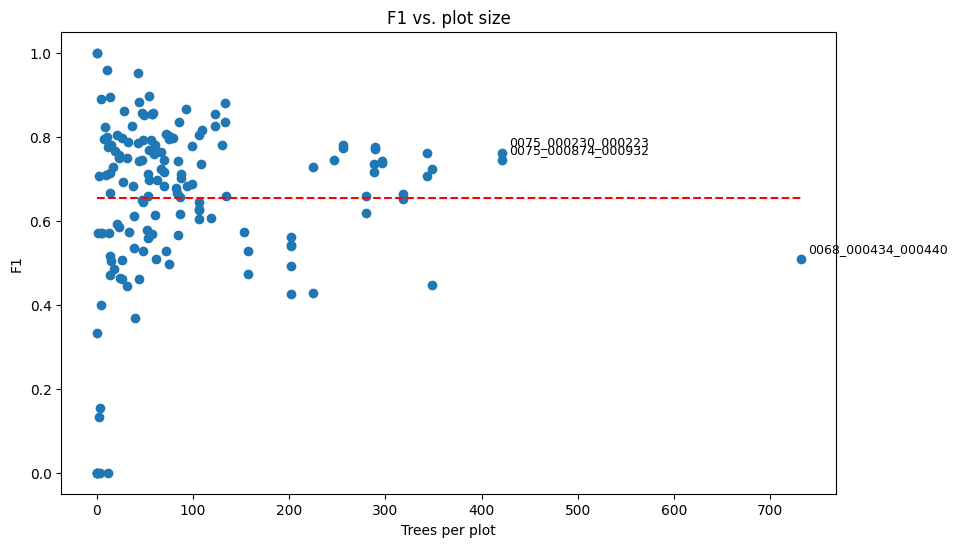

In [38]:
plt.figure(figsize=(10, 6))
plt.scatter(data["n_core_field"], data["recall"])
plt.title("Recall vs. plot size")
plt.xlabel("Trees per plot")
plt.ylabel("Recall")

# Annotate the three points with highest n_core_field
top_three = data.nlargest(3, "n_core_field")
for idx, row in top_three.iterrows():
    plt.annotate(row["dataset_id"], (row["n_core_field"], row["recall"]),
                xytext=(5, 5), textcoords='offset points', fontsize=9)

x_axis = np.linspace(0, data["n_core_field"].max())
mean_recall = np.ones_like(x_axis) * mean_values["recall"]
plt.plot(x_axis, mean_recall, linestyle="dashed", c="r")
plt.plot()
plt.show()
plt.close()

plt.figure(figsize=(10, 6))
plt.scatter(data["n_core_field"], data["precision"])
plt.title("Precision vs. plot size")
plt.xlabel("Trees per plot")
plt.ylabel("Precision")

# Annotate the three points with highest n_core_field
top_three = data.nlargest(3, "n_core_field")
for idx, row in top_three.iterrows():
    plt.annotate(row["dataset_id"], (row["n_core_field"], row["precision"]),
                xytext=(5, 5), textcoords='offset points', fontsize=9)

mean_precision = np.ones_like(x_axis) * mean_values["precision"]
plt.plot(x_axis, mean_precision, linestyle="dashed", c="r")

plt.show()
plt.close()


plt.figure(figsize=(10, 6))
plt.scatter(data["n_core_field"], data["F1"])
plt.title("F1 vs. plot size")
plt.xlabel("Trees per plot")
plt.ylabel("F1")

# Annotate the three points with highest n_core_field
top_three = data.nlargest(3, "n_core_field")
for idx, row in top_three.iterrows():
    plt.annotate(row["dataset_id"], (row["n_core_field"], row["F1"]),
                xytext=(5, 5), textcoords='offset points', fontsize=9)

mean_F1 = np.ones_like(x_axis) * mean_values["F1"]
plt.plot(x_axis, mean_F1, linestyle="dashed", c="r")

plt.show()
plt.close()

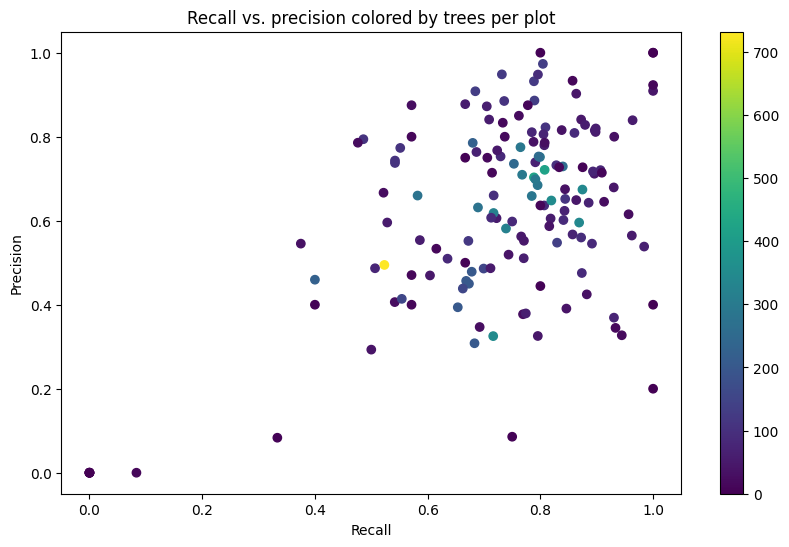

             recall  precision
recall     1.000000   0.553738
precision  0.553738   1.000000


In [37]:
plt.figure(figsize=(10, 6))
plt.scatter(data["recall"],data["precision"], c=data["n_core_field"])
plt.colorbar()
plt.title("Recall vs. precision colored by trees per plot")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()
print(data[["recall", "precision"]].corr())

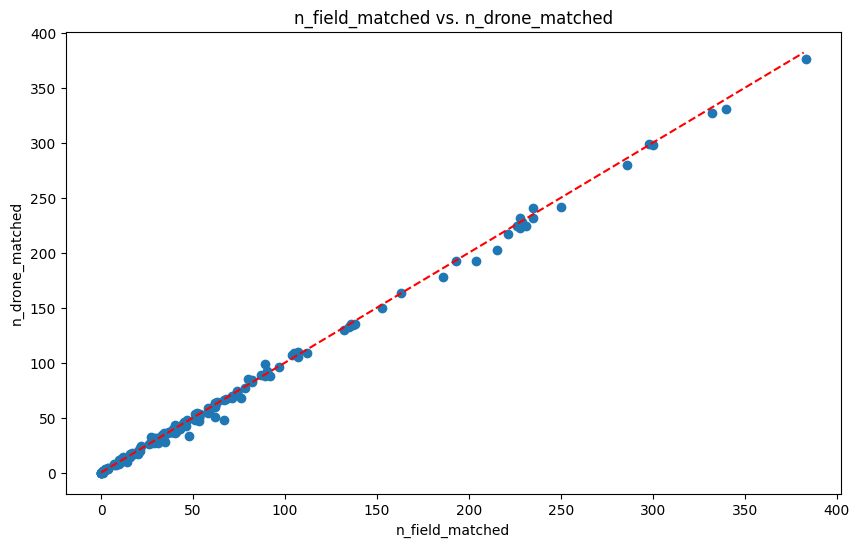

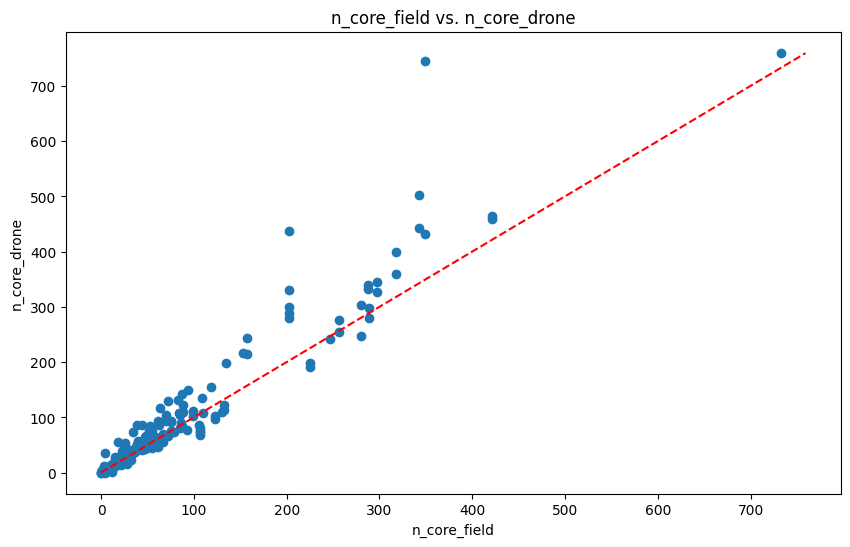

In [45]:
plt.figure(figsize=(10, 6))
plt.scatter(data["n_field_matched"],data["n_drone_matched"])
plt.title("n_field_matched vs. n_drone_matched")
plt.xlabel("n_field_matched")
plt.ylabel("n_drone_matched")
plt.plot(np.arange(0, data["n_field_matched"].max()), np.arange(0, data["n_field_matched"].max()), linestyle="dashed", color="r")
plt.show()


plt.figure(figsize=(10, 6))
plt.scatter(data["n_core_field"],data["n_core_drone"])
plt.title("n_core_field vs. n_core_drone")
plt.xlabel("n_core_field")
plt.ylabel("n_core_drone")
plt.plot(np.arange(0, data["n_core_drone"].max()), np.arange(0, data["n_core_drone"].max()), linestyle="dashed", color="r")
plt.show()